In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import pandas as pd
import zipfile

zip_file = "Combined Data.csv.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    csv_name = zip_ref.namelist()[0]   # Gets the first CSV file
    df = pd.read_csv(zip_ref.open(csv_name))

In [3]:
df

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...,...
53038,53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [4]:
df.shape

(53043, 3)

In [5]:
df.columns

Index(['Unnamed: 0', 'statement', 'status'], dtype='object')

In [6]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Unnamed: 0     int64
statement     object
status        object
dtype: object


In [7]:
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [8]:
df.tail()

,Unnamed: 0,statement,status
53038,53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety
53042,53042,I have really bad door anxiety! It's not about...,Anxiety


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [10]:
df.describe()

,Unnamed: 0
count,53043.000000
mean,26521.000000
std,15312.339501
min,0.000000
25%,13260.500000
50%,26521.000000
75%,39781.500000
max,53042.000000


In [11]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [12]:
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


Handiling null values

In [13]:
df.isnull().sum()

statement    362
status         0
dtype: int64

In [14]:
df.dropna(subset=['statement', 'status'], inplace=True)

In [15]:
df.isnull().sum()

statement    0
status       0
dtype: int64

In [16]:
df.shape

(52681, 2)

Handling Duplicated values

In [17]:
df.duplicated().sum()

np.int64(1588)

In [18]:
df.drop_duplicates(inplace=True)

In [19]:
df.shape

(51093, 2)

In [20]:
df.reset_index(drop=True, inplace=True)

Check Class Distribution

In [21]:
df["status"].value_counts()

status
Normal                  16040
Depression              15094
Suicidal                10644
Anxiety                  3623
Bipolar                  2501
Stress                   2296
Personality disorder      895
Name: count, dtype: int64

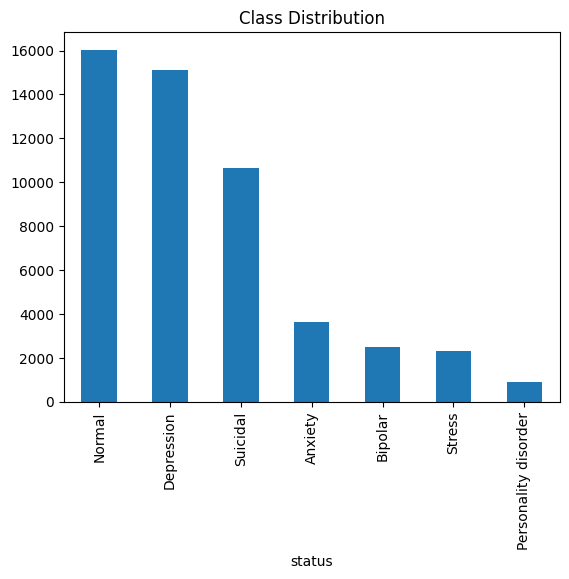

In [22]:
df['status'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

In [23]:
df['text_length'] = df['statement'].apply(len)

df['text_length'].describe()

count    51093.000000
mean       575.600141
std        847.947705
min          2.000000
25%         79.000000
50%        313.000000
75%        745.000000
max      32759.000000
Name: text_length, dtype: float64

# **NLP**

In [24]:
import re
import string

**Lowercase**: coverting statements to lowercase

In [25]:
df["statement"]=df["statement"].str.lower()

In [26]:
df["statement"].head()

0                                           oh my gosh
1    trouble sleeping, confused mind, restless hear...
2    all wrong, back off dear, forward doubt. stay ...
3    i've shifted my focus to something else but i'...
4    i'm restless and restless, it's been a month n...
Name: statement, dtype: object

Remove HTML Tags

In [27]:
from bs4 import BeautifulSoup

In [28]:
def remove_html(statement):
  return BeautifulSoup(statement,"html.parser").get_text()

In [29]:
df["statement"]=df["statement"].apply(remove_html)

C:\Users\anant\AppData\Local\Temp\ipykernel_26520\3012302149.py:2: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return BeautifulSoup(statement,"html.parser").get_text()


Remove URLs

In [30]:
def remove_urls(statement):
  return re.sub(r'http\S+|www\S+','',statement)

In [31]:
df["statement"]=df["statement"].apply(remove_urls)

Remove Email Addresses

In [32]:
def remove_email(statement):
    return re.sub(r'\S+@\S+','',statement)

In [33]:
df["statement"]=df["statement"].apply(remove_email)

Remove Emojis


In [34]:
pip install emoji



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import emoji


In [36]:
def remove_emoji(statement):
    return emoji.replace_emoji(statement,replace='')

In [37]:
df["statement"] = df["statement"].apply(remove_emoji)

Expand Contractions

In [38]:
pip install contractions

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import contractions

In [40]:
def expand(statement):
    return contractions.fix(statement)

In [41]:
df["statement"]=df["statement"].apply(expand)

Remove Numbers

In [42]:
def remove_numbers(statement):
    return re.sub(r'\d+','',statement)

In [43]:
df["statement"] = df["statement"].apply(remove_numbers)

Remove Punctuation

In [44]:
 def remove_punctuation(statement):
   return statement.translate(str.maketrans('', '', string.punctuation))


In [45]:
 df["statement"] = df["statement"].apply(remove_punctuation)

Remove Special Characters

In [46]:
def remove_special_characters(statement):
    return re.sub(r'[^a-zA-Z\s]', '', statement)

In [47]:
df["statement"] = df["statement"].apply(remove_special_characters)

Remove Extra Spaces

In [48]:
def remove_extra_spaces(statement):
    return re.sub(r'\s+', ' ', statement).strip()

In [49]:
df["statement"] = df["statement"].apply(remove_extra_spaces)

# Tokenization

In [50]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
nltk.download('stopwords')

from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\anant\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\anant\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anant\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df["tokens"]=df["statement"].apply(word_tokenize)

Remove Stopwords

In [ ]:
stop_words = set(stopwords.words('english'))
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

In [ ]:
df["tokens"] = df["tokens"].apply(remove_stopwords)

# Lemmatization

In [ ]:
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\anant\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\anant\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
lemmatizer = WordNetLemmatizer()
def lemmatize_words(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

In [ ]:
df["tokens"] = df["tokens"].apply(lemmatize_words)

Convert Tokens Back to Sentence

In [ ]:
def join_tokens(tokens):
    return " ".join(tokens)

In [ ]:
df["statement"] = df["tokens"].apply(join_tokens)

In [ ]:
df.drop("tokens", axis=1, inplace=True)

In [ ]:
df.drop("text_length", axis=1, inplace=True)

Check Final Output

In [ ]:
df.head()

,statement,status
0,oh gosh,Anxiety
1,trouble sleeping confused mind restless heart ...,Anxiety
2,wrong back dear forward doubt stay restless re...,Anxiety
3,shifted focus something else still worried,Anxiety
4,restless restless month boy mean,Anxiety


Word Cloud

In [ ]:
!pip install wordcloud


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


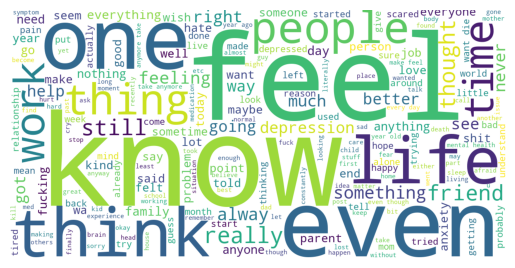

In [ ]:
from wordcloud import WordCloud

text = " ".join(df["statement"])

wordcloud = WordCloud(width=1200, height=600, background_color="white").generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [ ]:
from collections import Counter

words = " ".join(df["statement"]).split()

Counter(words).most_common(20)

[('like', 37110),
 ('feel', 34354),
 ('want', 28439),
 ('know', 25547),
 ('life', 22554),
 ('get', 22411),
 ('time', 20492),
 ('would', 18101),
 ('even', 18098),
 ('people', 16456),
 ('year', 16017),
 ('day', 15885),
 ('really', 15860),
 ('thing', 15719),
 ('one', 14977),
 ('going', 13908),
 ('think', 13269),
 ('go', 13211),
 ('friend', 12841),
 ('make', 12159)]

# Label Encoding

In [ ]:
df["status"].unique()

array(['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress', 'Bipolar',
       'Personality disorder'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["status"] = encoder.fit_transform(df["status"])

In [ ]:
label_mapping = dict(zip(encoder.classes_,
                         encoder.transform(encoder.classes_)))

print(label_mapping)

{'Anxiety': np.int64(0), 'Bipolar': np.int64(1), 'Depression': np.int64(2), 'Normal': np.int64(3), 'Personality disorder': np.int64(4), 'Stress': np.int64(5), 'Suicidal': np.int64(6)}


Separate X and y

In [ ]:
X = df["statement"]

y = df["status"]

# Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Bag of Words

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
# Create CountVectorizer
bow = CountVectorizer(max_features=10000)
# Fit only on training data
X_train_bow = bow.fit_transform(X_train)
# Transform test data
X_test_bow = bow.transform(X_test)
# Convert sparse matrix to dense array
X_train_bow = X_train_bow.toarray()
X_test_bow = X_test_bow.toarray()
print("Training Shape :", X_train_bow.shape)
print("Testing Shape  :", X_test_bow.shape)

Training Shape : (40874, 10000)
Testing Shape  : (10219, 10000)


# TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=10000)

# Fit only on training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data
X_test_tfidf = tfidf.transform(X_test)

# Convert sparse matrix to dense array
X_train_tfidf = X_train_tfidf.toarray()
X_test_tfidf = X_test_tfidf.toarray()

print("Training Shape :", X_train_tfidf.shape)
print("Testing Shape  :", X_test_tfidf.shape)

Training Shape : (40874, 10000)
Testing Shape  : (10219, 10000)


# Word2Vec

In [ ]:
!pip install gensim


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking

In [ ]:
!pip install -U gensim


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from gensim.models import Word2Vec


Train Word2Vec

In [ ]:
word2vec_model = Word2Vec(
    sentences=train_sentences,
    vector_size=300,
    window=5,
    min_count=3,
    workers=4,
    sg=1,
    negative=10,
    epochs=20
)

MAX_LEN = 100
EMBEDDING_DIM = 300

NameError: name 'train_sentences' is not defined

In [ ]:


def sentence_to_sequence(sentence):
    words = sentence.split()

    vectors = []

    for word in words:
        if word in word2vec_model.wv:
            vectors.append(word2vec_model.wv[word])

    return vectors

In [ ]:
X_train_seq = [sentence_to_sequence(text) for text in X_train]
X_test_seq = [sentence_to_sequence(text) for text in X_test]

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [ ]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    dtype='float32',
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    dtype='float32',
    padding='post',
    truncating='post'
)

In [ ]:
print(X_train_pad.shape)
print(X_test_pad.shape)

(40874, 100, 300)
(10219, 100, 300)


Build LSTM Model

In [ ]:
num_classes = len(np.unique(y_train))

model = Sequential()

model.add(Masking(mask_value=0.0,
                  input_shape=(MAX_LEN, EMBEDDING_DIM)))

model.add(LSTM(64))

model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(num_classes, activation='softmax'))

C:\Users\anant\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0005
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
199/511 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.4072 - loss: 1.5692 

KeyboardInterrupt: 

In [ ]:
y_pred = model.predict(X_test_pad)

y_pred = np.argmax(y_pred, axis=1)

320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.7462569723064879
              precision    recall  f1-score   support

           0       0.78      0.76      0.77       725
           1       0.74      0.70      0.72       500
           2       0.69      0.66      0.67      3019
           3       0.91      0.93      0.92      3208
           4       0.45      0.24      0.31       179
           5       0.64      0.27      0.37       459
           6       0.61      0.75      0.67      2129

    accuracy                           0.75     10219
   macro avg       0.69      0.61      0.64     10219
weighted avg       0.75      0.75      0.74     10219



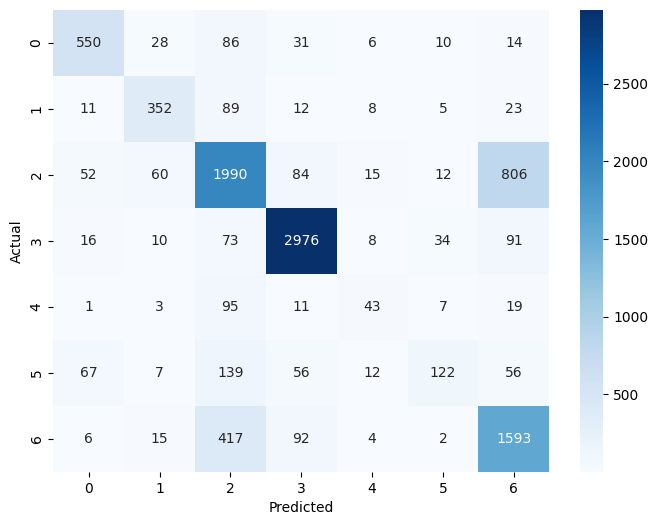

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

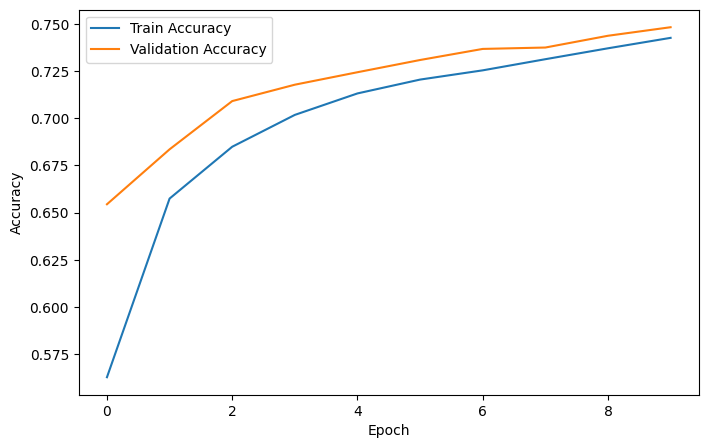

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

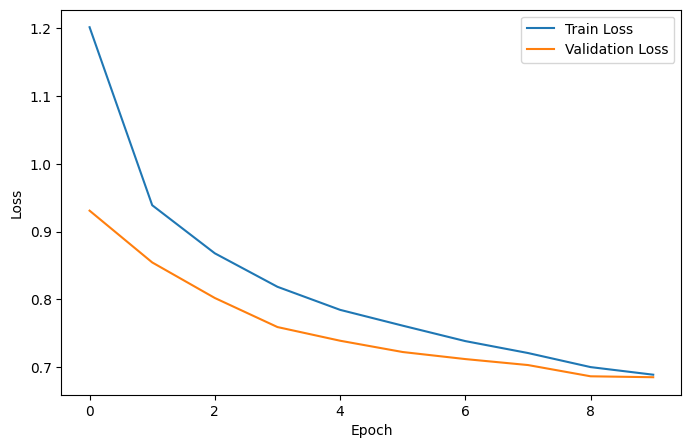

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# BiLSTM Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, Bidirectional, LSTM
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

model = Sequential()

model.add(
    Masking(
        mask_value=0.0,
        input_shape=(MAX_LEN, EMBEDDING_DIM)
    )
)

model.add(
    Bidirectional(
        LSTM(
            64,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.3
        )
    )
)

model.add(
    Bidirectional(
        LSTM(
            32,
            dropout=0.3,
            recurrent_dropout=0.3
        )
    )
)

model.add(
    Dense(
        32,
        activation="relu",
        kernel_regularizer=l2(0.001)
    )
)

model.add(Dropout(0.5))

model.add(Dense(num_classes, activation="softmax"))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 100, 300)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │       186,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 230,407 (900.03 KB)

 Trainable params: 230,407 (900.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0003
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 159s 146ms/step - accuracy: 0.4506 - loss: 1.5587 - val_accuracy: 0.6196 - val_loss: 1.0084 - learning_rate: 3.0000e-04
Epoch 2/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 168s 164ms/step - accuracy: 0.5919 - loss: 1.1139 - val_accuracy: 0.6871 - val_loss: 0.8776 - learning_rate: 3.0000e-04
Epoch 3/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 182s 178ms/step - accuracy: 0.6385 - loss: 1.0042 - val_accuracy: 0.7035 - val_loss: 0.8205 - learning_rate: 3.0000e-04
Epoch 4/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 168s 164ms/step - accuracy: 0.6706 - loss: 0.9316 - val_accuracy: 0.7187 - val_loss: 0.7831 - learning_rate: 3.0000e-04
Epoch 5/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 167s 163ms/step - accuracy: 0.6868 - loss: 0.8922 - val_accuracy: 0.7248 - val_loss: 0.7591 - learning_rate: 3.0000e-04
Epoch 6/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 169s 166ms/step - accuracy: 0.6951 - loss: 0.8622 - val_accuracy: 0.7311 - val_loss: 0.7394 - learning_rate: 3.0000e-04
Epoch 7/20
1022/1022 ━━━━━━━

In [ ]:
import numpy as np

y_pred = model.predict(X_test_pad)
y_pred = np.argmax(y_pred, axis=1)

320/320 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7667090713377043
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       725
           1       0.83      0.73      0.77       500
           2       0.73      0.66      0.69      3019
           3       0.90      0.94      0.92      3208
           4       0.82      0.35      0.49       179
           5       0.57      0.48      0.52       459
           6       0.63      0.75      0.68      2129

    accuracy                           0.77     10219
   macro avg       0.76      0.68      0.70     10219
weighted avg       0.77      0.77      0.76     10219



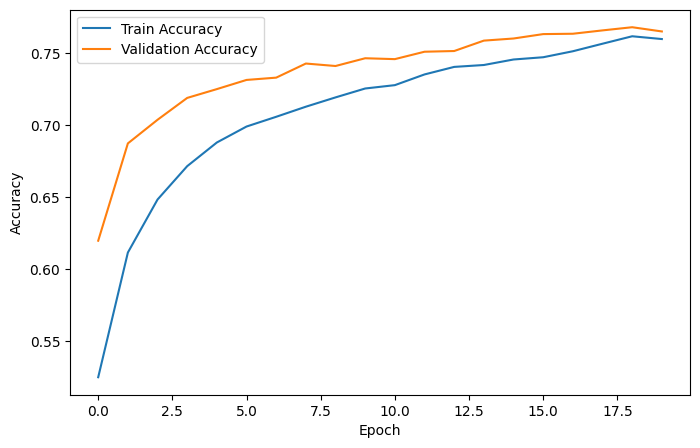

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

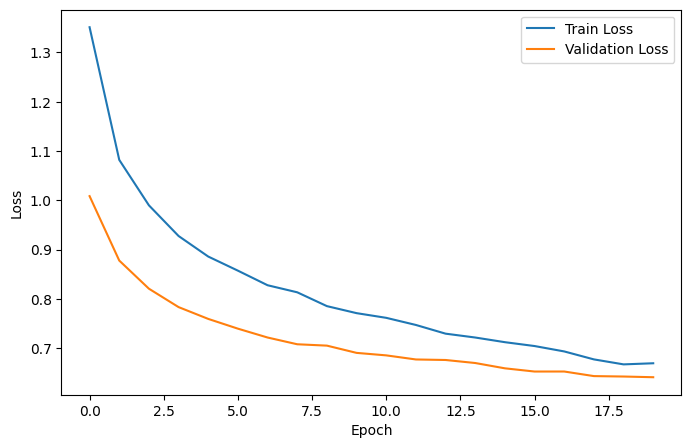

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

GRU 


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Masking
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
model = Sequential()

# Ignore padded vectors
model.add(
    Masking(
        mask_value=0.0,
        input_shape=(MAX_LEN, EMBEDDING_DIM)
    )
)

# First GRU Layer
model.add(
    GRU(
        128,
        return_sequences=True
    )
)

model.add(Dropout(0.4))

# Second GRU Layer
model.add(
    GRU(64)
)

model.add(Dropout(0.3))

# Dense Layer
model.add(Dense(64, activation='relu'))

model.add(Dropout(0.3))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

model.summary()

C:\Users\anant\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_2 (Masking)             │ (None, 100, 300)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 100, 128)       │       165,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,983 (808.53 KB)

 Trainable params: 206,983 (808.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 120s 112ms/step - accuracy: 0.5665 - loss: 1.1661 - val_accuracy: 0.7295 - val_loss: 0.7305 - learning_rate: 0.0010
Epoch 2/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 108s 105ms/step - accuracy: 0.7254 - loss: 0.7509 - val_accuracy: 0.7552 - val_loss: 0.6527 - learning_rate: 0.0010
Epoch 3/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 108s 105ms/step - accuracy: 0.7590 - loss: 0.6472 - val_accuracy: 0.7594 - val_loss: 0.6532 - learning_rate: 0.0010
Epoch 4/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 108s 105ms/step - accuracy: 0.7756 - loss: 0.6025 - val_accuracy: 0.7626 - val_loss: 0.6315 - learning_rate: 0.0010
Epoch 5/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 106s 104ms/step - accuracy: 0.7876 - loss: 0.5674 - val_accuracy: 0.7629 - val_loss: 0.6317 - learning_rate: 0.0010
Epoch 6/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8025 - loss: 0.5263
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 107s 104ms/ste

In [ ]:
import numpy as np

y_pred = model.predict(X_test_pad)

y_pred = np.argmax(y_pred, axis=1)

320/320 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7584890889519522
              precision    recall  f1-score   support

           0       0.85      0.79      0.81       725
           1       0.83      0.70      0.76       500
           2       0.74      0.61      0.67      3019
           3       0.90      0.94      0.92      3208
           4       0.97      0.32      0.49       179
           5       0.57      0.49      0.53       459
           6       0.60      0.79      0.68      2129

    accuracy                           0.76     10219
   macro avg       0.78      0.66      0.69     10219
weighted avg       0.77      0.76      0.76     10219



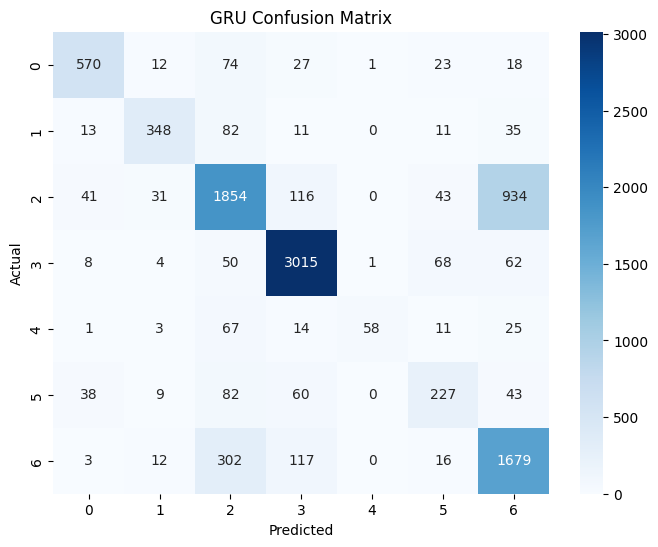

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU Confusion Matrix")
plt.show()

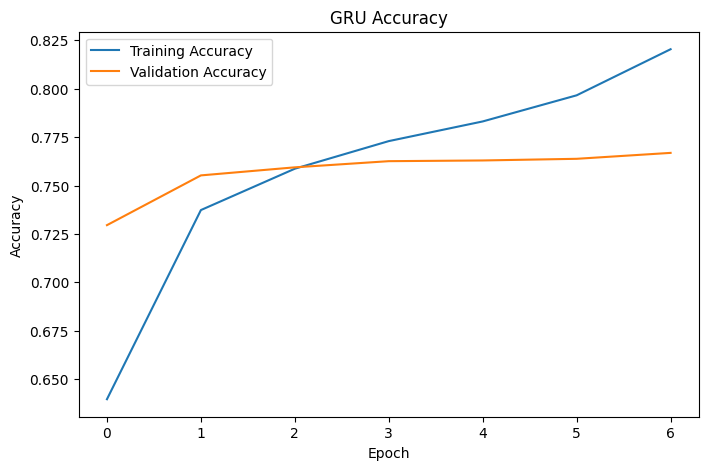

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('GRU Accuracy')
plt.legend()
plt.show()

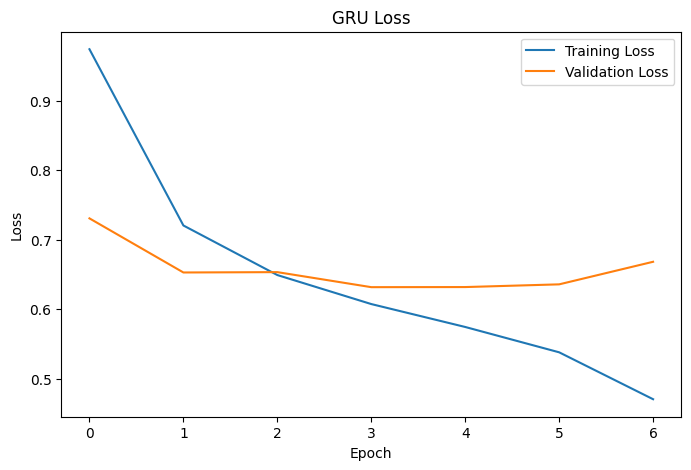

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GRU Loss')
plt.legend()
plt.show()

BERT MODEL

In [ ]:
import transformers
print(transformers.__version__)

5.14.1


In [ ]:
!pip install transformers datasets accelerate -q


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch

from transformers import (
    BertTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

In [ ]:
tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

In [ ]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [ ]:
class MentalHealthDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

Load BERT Model

In [ ]:
train_dataset = MentalHealthDataset(
    train_encodings,
    y_train.tolist()
)

test_dataset = MentalHealthDataset(
    test_encodings,
    y_test.tolist()
)

In [ ]:
num_classes = len(np.unique(y_train))

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_classes
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def compute_metrics(pred):

    labels = pred.label_ids

    preds = np.argmax(pred.predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./bert_results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    logging_dir="./logs",

    logging_steps=100,

    report_to="none"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
import transformers
print(transformers.__version__)

5.14.1


In [ ]:
trainer.train()

KeyboardInterrupt: 

In [ ]:
trainer.evaluate()

In [ ]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
validation_df = pd.read_excel("NLP_External_Validation_100_New_Statements(1).xlsx")

print(validation_df.head())

In [ ]:
validation_df["statement"] = validation_df["statement"].str.lower()

validation_df["statement"] = validation_df["statement"].apply(remove_html)
validation_df["statement"] = validation_df["statement"].apply(remove_urls)
validation_df["statement"] = validation_df["statement"].apply(remove_email)
validation_df["statement"] = validation_df["statement"].apply(remove_emoji)
validation_df["statement"] = validation_df["statement"].apply(expand)
validation_df["statement"] = validation_df["statement"].apply(remove_numbers)
validation_df["statement"] = validation_df["statement"].apply(remove_punctuation)
validation_df["statement"] = validation_df["statement"].apply(remove_special_characters)
validation_df["statement"] = validation_df["statement"].apply(remove_extra_spaces)

validation_df["tokens"] = validation_df["statement"].apply(word_tokenize)
validation_df["tokens"] = validation_df["tokens"].apply(remove_stopwords)
validation_df["tokens"] = validation_df["tokens"].apply(lemmatize_words)

validation_df["statement"] = validation_df["tokens"].apply(join_tokens)

validation_df.drop("tokens", axis=1, inplace=True)

In [ ]:
X_external_seq = [
    sentence_to_sequence(text)
    for text in validation_df["statement"]
]

In [ ]:
X_external_pad = pad_sequences(
    X_external_seq,
    maxlen=MAX_LEN,
    dtype="float32",
    padding="post",
    truncating="post"
)

In [ ]:
pred = model.predict(X_external_pad)

pred_classes = np.argmax(pred, axis=1)

In [ ]:
predicted_status = encoder.inverse_transform(pred_classes)

validation_df["Predicted_Status"] = predicted_status

validation_df["Confidence"] = np.max(pred, axis=1)

In [ ]:
print("Accuracy:",
      accuracy_score(validation_df["status"],
                     validation_df["Predicted_Status"]))

print(classification_report(
    validation_df["status"],
    validation_df["Predicted_Status"]
))

In [ ]:
cm = confusion_matrix(
    validation_df["status"],
    validation_df["Predicted_Status"]
)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BiLSTM External Validation")
plt.show()